### Customer retention is a key challenge in the banking industry
Focusing on predicting customer churn—whether a customer is likely to leave the bank—using demographic, account, and behavioral information.

Participants are tasked with building a binary classification model to predict the target variable Exited, where:

1 = Customer churned (left the bank)

0 = Customer remained with the bank

### Evaluation
Submissions will be evaluated using "Accuracy".

Accuracy measures the proportion of correctly classified customers and is calculated as:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

#### import library

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report 

In [170]:
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cpu


In [171]:
# Load the dataset
data = pd.read_csv("train.csv")
test_data = pd.read_csv("test_without_labels.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0
1,6618,15700826,Ko,678,Germany,Female,54,1,123699.28,2,0,1,105221.76,0
2,6622,15710365,Thomson,646,France,Male,50,0,104129.24,2,1,0,181794.86,1
3,6627,15619932,Lombardi,847,France,Male,66,7,123760.68,1,0,1,53157.16,0
4,8353,15641413,Crawford,587,Germany,Female,49,7,155393.98,2,1,0,13308.20,1


In [172]:
# shape of the dataset
print(f"Shape of the dataset: {data.shape}")

Shape of the dataset: (7000, 14)


### preprocessing the data

In [173]:
# drop the 'RowNumber', 'Surname' column as it is not useful for prediction
data = data.drop(['RowNumber', 'Surname'], axis=1)
test_data_pre = test_data.drop(['RowNumber', 'Surname'], axis=1)

In [174]:
# one-hot encode categorical variables
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
test_data_pre = pd.get_dummies(test_data_pre, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
data.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,15769110,653,46,5,0.00,2,1,0,49707.85,0,0,0,0
1,15700826,678,54,1,123699.28,2,0,1,105221.76,0,1,0,0
2,15710365,646,50,0,104129.24,2,1,0,181794.86,1,0,0,1
3,15619932,847,66,7,123760.68,1,0,1,53157.16,0,0,0,1
4,15641413,587,49,7,155393.98,2,1,0,13308.20,1,1,0,0


In [175]:
# correlation matrix
correlation_matrix = data.corr()
correlation_matrix["Exited"].sort_values(ascending=False)

Exited               1.000000
Age                  0.375804
Geography_Germany    0.320158
Balance              0.237334
EstimatedSalary      0.018328
HasCrCard            0.006205
CustomerId          -0.005307
Tenure              -0.063052
Gender_Male         -0.093804
Geography_Spain     -0.097803
CreditScore         -0.108203
NumOfProducts       -0.190115
IsActiveMember      -0.404305
Name: Exited, dtype: float64

we see that 'HasCrCard' and 'CustomerId' are not useful for prediction, so we will drop them also.

In [176]:
# drop the 'HasCrCard' and 'CustomerId' columns as they are not useful for prediction
data = data.drop(['HasCrCard', 'CustomerId'], axis=1)
test_data_pre = test_data_pre.drop(['HasCrCard', 'CustomerId'], axis=1)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,653,46,5,0.00,2,0,49707.85,0,0,0,0
1,678,54,1,123699.28,2,1,105221.76,0,1,0,0
2,646,50,0,104129.24,2,0,181794.86,1,0,0,1
3,847,66,7,123760.68,1,1,53157.16,0,0,0,1
4,587,49,7,155393.98,2,0,13308.20,1,1,0,0


In [177]:
# split the dataset into training and validation sets

feature_cols = data.drop('Exited', axis=1).columns
X = data[feature_cols].values
y = data['Exited'].values

# scale the features using Min-Max scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
# apply the same scaling to the test data
if hasattr(test_data_pre, 'columns'):
    test_data_pre = scaler.transform(test_data_pre[feature_cols].values)
else:
    test_data_pre = scaler.transform(test_data_pre)


### Building a predictive model (NN with Torch)

In [178]:
# initialize the features and target variable to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).to(device)

X_tensor.shape, y_tensor.shape


(torch.Size([7000, 10]), torch.Size([7000]))

In [179]:
# Custom Dataset class for our bank customers data
class BankCustomersDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

bank_dataset = BankCustomersDataset(X_tensor, y_tensor)
print(f"Length of the dataset: {len(bank_dataset)}")
print(f"Sample data: {bank_dataset[0]}")

Length of the dataset: 7000
Sample data: (tensor([0.6060, 0.3784, 0.5000, 0.0000, 0.3333, 0.0000, 0.2485, 0.0000, 0.0000,
        0.0000]), tensor(0.))


In [180]:
# data loader
batch_size = 32
BankCustomers = DataLoader(
                bank_dataset,
                batch_size=batch_size,
                shuffle=True
            )
for batch_idx, (X_batch, y_batch) in enumerate(BankCustomers):
    print(f"Batch {batch_idx + 1}:")
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")
    break

Batch 1:
X_batch shape: torch.Size([32, 10])
y_batch shape: torch.Size([32])


In [181]:
# building NN class
class BankCustomerNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # output layer with sigmoid activation for binary classification
        )
    def forward(self, x):
        return self.net(x).squeeze(1)  # returns probabilities

model = BankCustomerNN(input_dim=X_tensor.shape[1]).to(device)

In [182]:
# training the model
def train_model(model, dataloader, criterion, optimizer, epochs=10, device=device):
    model.train()
    loss_history = []
    
    for epoch in range(epochs):
        running_loss = 0.0
        
        for i, (inputs, labels) in enumerate(dataloader):
            optimizer.zero_grad()
            
            outputs = model(inputs)
            
            loss = criterion(outputs.squeeze(), labels)
            
            loss.backward()
            
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss / len(dataloader):.4f}")
        loss_history.append(running_loss / len(dataloader))
    return loss_history

Training the model...
Epoch [1/100], Loss: 0.0806
Epoch [2/100], Loss: 0.0776
Epoch [3/100], Loss: 0.0766
Epoch [4/100], Loss: 0.0719
Epoch [5/100], Loss: 0.0694
Epoch [6/100], Loss: 0.0720
Epoch [7/100], Loss: 0.0691
Epoch [8/100], Loss: 0.0705
Epoch [9/100], Loss: 0.0690
Epoch [10/100], Loss: 0.0669
Epoch [11/100], Loss: 0.0676
Epoch [12/100], Loss: 0.0645
Epoch [13/100], Loss: 0.0676
Epoch [14/100], Loss: 0.0674
Epoch [15/100], Loss: 0.0664
Epoch [16/100], Loss: 0.0684
Epoch [17/100], Loss: 0.0636
Epoch [18/100], Loss: 0.0654
Epoch [19/100], Loss: 0.0638
Epoch [20/100], Loss: 0.0663
Epoch [21/100], Loss: 0.0631
Epoch [22/100], Loss: 0.0659
Epoch [23/100], Loss: 0.0637
Epoch [24/100], Loss: 0.0656
Epoch [25/100], Loss: 0.0640
Epoch [26/100], Loss: 0.0646
Epoch [27/100], Loss: 0.0610
Epoch [28/100], Loss: 0.0637
Epoch [29/100], Loss: 0.0640
Epoch [30/100], Loss: 0.0639
Epoch [31/100], Loss: 0.0620
Epoch [32/100], Loss: 0.0635
Epoch [33/100], Loss: 0.0638
Epoch [34/100], Loss: 0.0621
E

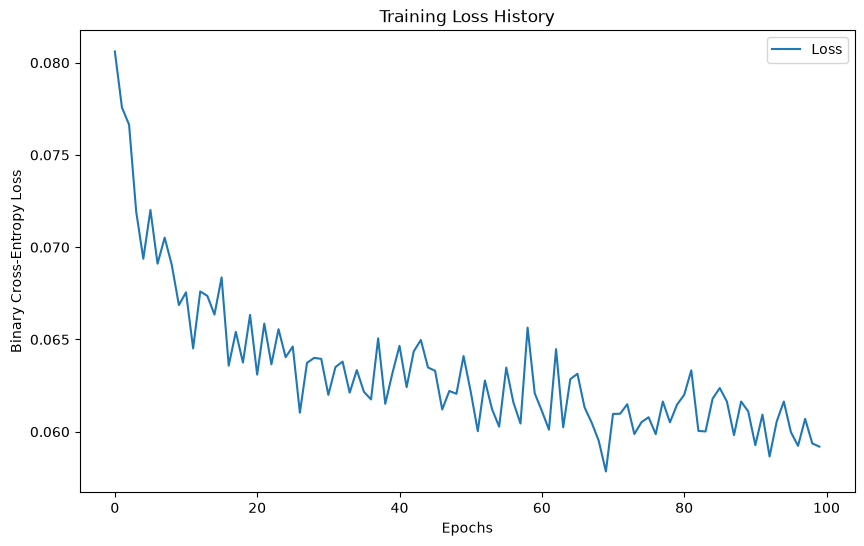

In [191]:
# selecting the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.BCELoss()
print("Training the model...")
loss_history = train_model(model, BankCustomers, criterion, optimizer, epochs=100)
# Visualizing the loss history
plt.plot(loss_history, label="Loss")
plt.title("Training Loss History")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

In [192]:
# Evaluate the model on the training data
model.eval()
with torch.no_grad():
    y_pred = model(X_tensor)
    y_pred_class = (y_pred >= 0.5).int()  # convert probabilities to binary class labels
# Accuracy
accuracy = accuracy_score(y_tensor.cpu(), y_pred_class.cpu())
classification = classification_report(y_tensor.cpu(), y_pred_class.cpu())

# print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Classification Report:\n{classification}")


Accuracy: 0.9771
Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      5733
         1.0       0.96      0.91      0.94      1267

    accuracy                           0.98      7000
   macro avg       0.97      0.95      0.96      7000
weighted avg       0.98      0.98      0.98      7000



### Testing the model

In [193]:
# testing the model and saving the predictions to a CSV file
test_tensor = torch.tensor(test_data_pre, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    test_predictions = model(test_tensor)
test_predictions = (test_predictions >= 0.5).int()  # convert probabilities to binary class labels
submission = pd.DataFrame({'id': np.arange(len(test_data)), 'Exited': test_predictions.cpu().numpy().flatten()})
submission.to_csv("submission.csv", index=False)
